In [ ]:
# Optional setup commands for fresh environments (keep commented in local runs).
# !git clone https://github.com/recepgul82/music-digital-methods.git
# !pip install -r music-digital-methods/setup/requirements.txt

project path setup

In [1]:
# Import utilities for dynamic path detection and Python module path updates.
import sys
from pathlib import Path


def find_repo_root(marker_dir="course_code"):
    # Search upward from the current working directory first.
    p = Path.cwd().resolve()
    for _ in range(10):
        if (p / marker_dir).is_dir():
            return p
        if p == p.parent:
            break
        p = p.parent

    # Fallback: scan common roots (e.g., Colab /content) for the marker directory.
    for base in [Path("/content"), Path.cwd().resolve()]:
        if base.exists():
            for candidate in base.rglob(marker_dir):
                if candidate.is_dir():
                    return candidate.parent

    raise RuntimeError(f"Could not locate repo root containing '{marker_dir}/'.")


# Resolve repository root and make local package imports available.
REPO_ROOT = find_repo_root("course_code")
print("REPO_ROOT =", REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))



REPO_ROOT = /Users/recepgul/Desktop/ITU/Teaching/Doktora/LEE904E/music-digital-methods


1. We load required libraries for text processing, embeddings (Doc2Vec), clustering, and visualization

In [2]:
import pandas as pd
import numpy as np

# NLP
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
import nltk
from nltk.tokenize import word_tokenize

# Clustering
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics.pairwise import cosine_similarity

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import umap

nltk.download('punkt')

[nltk_data] Downloading package punkt to /Users/recepgul/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

2. We load the dataset and inspect its structure.

In [3]:
import os 

df = pd.read_csv(os.path.join(REPO_ROOT, "data/mirex_emotion.csv"), index_col=0)  # adjust path if needed
df.head()

,song_id,cluster,category,lyrics
0,1,Cluster 1,Boisterous,Mama he treats your daughter mean \nMama he tr...
1,2,Cluster 1,Boisterous,NaN
2,3,Cluster 1,Boisterous,I plopped down in my easy chair and turned on ...
3,4,Cluster 1,Boisterous,Back in black \nI hit the sack \nIt's been too...
4,5,Cluster 1,Boisterous,NaN


3. We check available columns and select the relevant ones (lyrics + emotion label).

In [4]:
df.columns

Index(['song_id', 'cluster', 'category', 'lyrics'], dtype='str')

4. We clean the dataset by removing missing values and limiting dataset size for visualization.

In [5]:
df = df[['lyrics', 'category']].dropna()

# For visualization clarity
df_sub = df.sample(250, random_state=42)
df_sub = df_sub.reset_index(drop=True)

df_sub.head(), df_sub.shape

(                                              lyrics     category
 0  As soon as you're born they make you feel smal...     Brooding
 1  Hey, little girl in the high school sweater\nG...        Sweet
 2  Down to the bus\ninto the town\nour poor boy c...     Volatile
 3  Last night I took a walk after dark\nA swingin...          Fun
 4  I fall to pieces\nEach time I see you again\nI...  Bittersweet,
 (250, 2))

### DOC2Vec

5. We tokenize lyrics and prepare them for Doc2Vec training.

In [6]:
documents = [
    TaggedDocument(words=word_tokenize(row.lower()), tags=[str(i)])
    for i, row in enumerate(df_sub['lyrics'])
]

6. We train a Doc2Vec model to obtain vector representations of each document (song).

* Doc2Vec learns embeddings where documents with similar context are close in vector space.

In [7]:
model = Doc2Vec(
    documents,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    epochs=40
)

7. We extract document embeddings (one vector per song).

In [8]:
X = np.array([model.dv[str(i)] for i in range(len(df_sub))])

X.shape

(250, 100)

8. We compute cosine similarity between documents.

* This shows how similar songs are in embedding space.

In [9]:
sim_matrix = cosine_similarity(X)

sim_matrix[:5, :5]

array([[0.99999994, 0.08899104, 0.15256216, 0.39077947, 0.4544549 ],
       [0.08899104, 1.0000001 , 0.22669232, 0.38323408, 0.16623951],
       [0.15256216, 0.22669232, 1.        , 0.55657583, 0.24041587],
       [0.39077947, 0.38323408, 0.55657583, 0.9999999 , 0.33527616],
       [0.4544549 , 0.16623951, 0.24041587, 0.33527616, 1.0000001 ]],
      dtype=float32)

### This heatmap shows pairwise similarity between songs.
* Higher values indicate stronger semantic similarity between lyrics.

9. We visualize the similarity matrix as a heatmap.

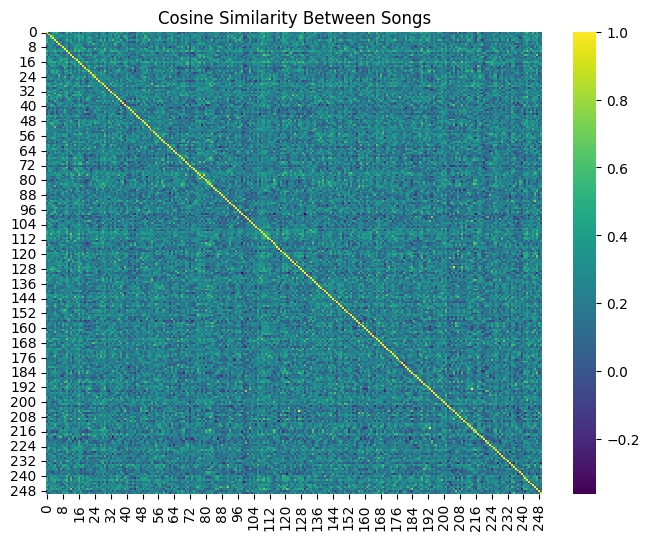

In [10]:
plt.figure(figsize=(8,6))
sns.heatmap(sim_matrix, cmap="viridis")
plt.title("Cosine Similarity Between Songs")
plt.show()

10. We apply KMeans clustering to group songs into semantic clusters.

In [11]:
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans_labels = kmeans.fit_predict(X)

11. We apply DBSCAN clustering to detect dense regions and noise points.

In [12]:
for eps in [0.1, 0.30, 0.45, 0.5, 0.55, 0.6]:
    db = DBSCAN(eps=eps, min_samples=5, metric='cosine')
    labels = db.fit_predict(X)
    print(eps, len(set(labels)), "clusters")

db = DBSCAN(eps=0.45, min_samples=5, metric='cosine')
db_labels = db.fit_predict(X)

0.1 1 clusters
0.3 1 clusters
0.45 3 clusters
0.5 2 clusters
0.55 2 clusters
0.6 1 clusters


12. We reduce dimensionality using UMAP to visualize embeddings in 2D.

* UMAP preserves local structure of high-dimensional data.

In [13]:
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
X_2d = reducer.fit_transform(X)

/Users/recepgul/Desktop/ITU/Teaching/Doktora/LEE904E/music-digital-methods/venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [14]:
from sklearn.cluster import MeanShift
from sklearn.cluster import estimate_bandwidth

bw = estimate_bandwidth(X, quantile=0.2)

ms = MeanShift(bandwidth=bw)
ms_labels = ms.fit_predict(X)
print(bw)

8.41695818901062


13. We visualize KMeans clustering results.

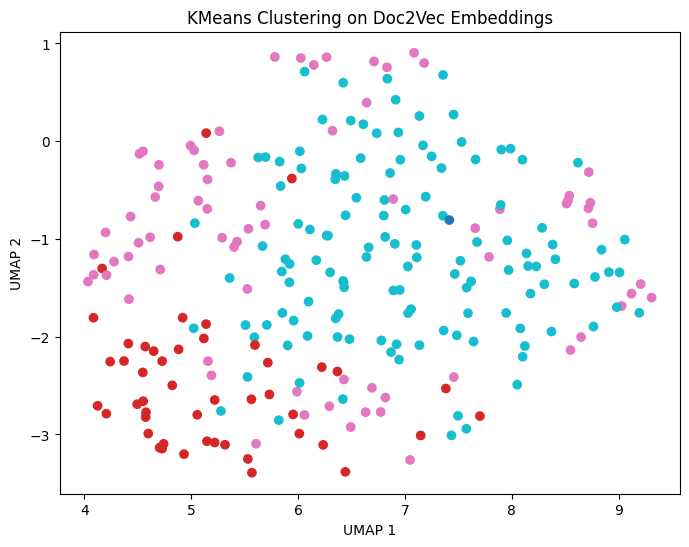

In [15]:
plt.figure(figsize=(8,6))
plt.scatter(X_2d[:,0], X_2d[:,1], c=kmeans_labels, cmap='tab10')
plt.title("KMeans Clustering on Doc2Vec Embeddings")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.show()

📊 Visualization Caption

Each point represents a song.
Colors indicate cluster membership.
Clusters correspond to latent themes or emotional groupings in lyrics.

14. We visualize DBSCAN clustering results.

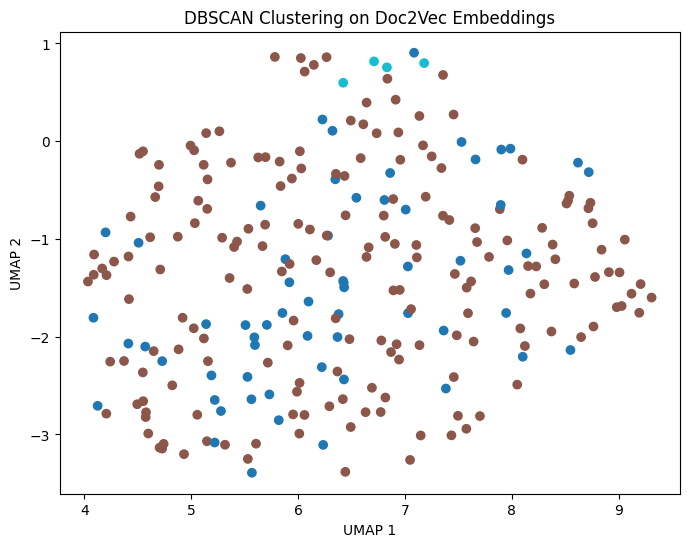

In [16]:
plt.figure(figsize=(8,6))
plt.scatter(X_2d[:,0], X_2d[:,1], c=db_labels, cmap='tab10')
plt.title("DBSCAN Clustering on Doc2Vec Embeddings")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.show()

15. We find two lyrics that are closest in the embedding space.

- Doc2Vec represents each document as a vector, allowing us to retrieve the most similar documents based on cosine similarity.

- We will:

1) pick one lyric
2) find its nearest neighbor
3) compare them

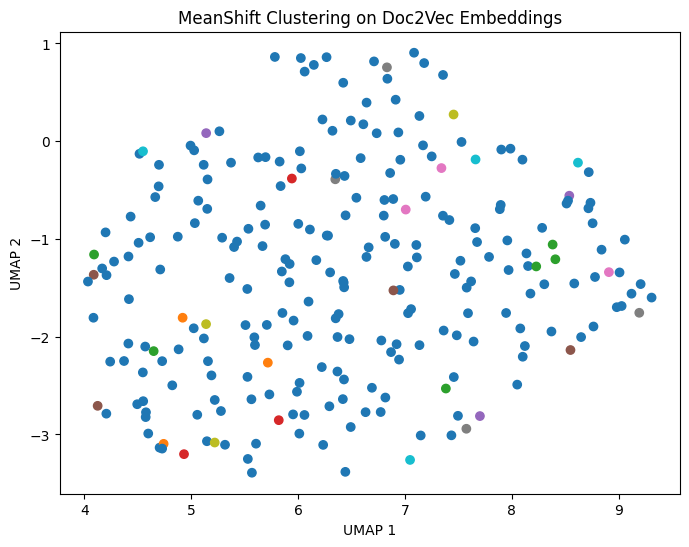

In [17]:
plt.figure(figsize=(8,6))
plt.scatter(X_2d[:,0], X_2d[:,1], c=ms_labels, cmap='tab10')
plt.title("MeanShift Clustering on Doc2Vec Embeddings")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.show()

In [18]:
df_sub['category'].unique()

<ArrowStringArray>
[            'Brooding',                'Sweet',             'Volatile',
                  'Fun',          'Bittersweet',                'Witty',
 'Amiable-good natured',           'Passionate',           'Rollicking',
             'Poignant',             'Literate',            'whimsical',
             'Humorous',                  'Wry',      'Tense - Anxious',
                'Fiery',                'Campy',            'Confident',
                'Rowdy',              'Wistful',                'Silly',
             'Visceral',             'Cheerful',              'Intense',
              'Rousing',           'Boisterous',            'Agressive',
             'Autumnal']
Length: 28, dtype: str

In [19]:
# find a song with a specific emotion (e.g., sadness)
idx = df_sub[df_sub['category'] == 'Sweet'].index[0]

similar_docs = model.dv.most_similar(str(idx), topn=5)
closest_idx = int(similar_docs[0][0])

print("Emotion:", df_sub.iloc[idx]['category'])

print("\n--- REFERENCE ---\n")
print(df.iloc[idx]['lyrics'][:400])

print("\n--- CLOSEST ---\n")
print(df.iloc[closest_idx]['lyrics'][:400])

print("\nSimilarity:", similar_docs[0][1])

Emotion: Sweet

--- REFERENCE ---

I plopped down in my easy chair and turned on Channel 2
A bad gunslinger called Salty Sam was chasin' poor Sweet Sue
He trapped her in the old sawmill and said with an evil laugh,
"If you don't give me the deed to your ranch
I'll saw you all in half!"
And then he grabbed her (and then)
He tied her up (and then)
He turned on the bandsaw (and then, and then...!)

[Chorus:]
And then along came Jones


--- CLOSEST ---

[Chorus:]
Don't go for second best baby
Put your love to the test you know, you know you've got to
Make him express how he feels and maybe
Then you'll know your love is real

You don't need diamond rings or eighteen karat gold
Fancy cars that go very fast you know they never last no, no
What you need is a big strong hand to
Life you to your higher ground
Make you feel like a queen on a throne
Make

Similarity: 0.5996172428131104


In [20]:
# get the most similar document (excluding itself)
closest_idx = int(similar_docs[0][0])
similarity_score = similar_docs[0][1]

print("Reference index:", idx)
print("Closest index:", closest_idx)
print("Similarity score:", similarity_score)

Reference index: 1
Closest index: 34
Similarity score: 0.5996172428131104


In [21]:
print("----- REFERENCE LYRIC -----\n")
print(df.iloc[idx]['lyrics'][:500])  # truncate for readability

print("\n\n----- MOST SIMILAR LYRIC -----\n")
print(df.iloc[closest_idx]['lyrics'][:500])

----- REFERENCE LYRIC -----

I plopped down in my easy chair and turned on Channel 2
A bad gunslinger called Salty Sam was chasin' poor Sweet Sue
He trapped her in the old sawmill and said with an evil laugh,
"If you don't give me the deed to your ranch
I'll saw you all in half!"
And then he grabbed her (and then)
He tied her up (and then)
He turned on the bandsaw (and then, and then...!)

[Chorus:]
And then along came Jones
Tall thin Jones
Slow-walkin' Jones
Slow-talkin' Jones
Along came long, lean, lanky Jones

Commercial


----- MOST SIMILAR LYRIC -----

[Chorus:]
Don't go for second best baby
Put your love to the test you know, you know you've got to
Make him express how he feels and maybe
Then you'll know your love is real

You don't need diamond rings or eighteen karat gold
Fancy cars that go very fast you know they never last no, no
What you need is a big strong hand to
Life you to your higher ground
Make you feel like a queen on a throne
Make him love you till you can't come do

### BERT

In [22]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# --- model (better than raw BERT) ---
model = SentenceTransformer("all-MiniLM-L6-v2")

# --- embed lyrics ---
embeddings = model.encode(df["lyrics"].tolist(), show_progress_bar=True)

# --- search function ---
def search(query, top_k=5):
    q_vec = model.encode([query])
    sims = cosine_similarity(q_vec, embeddings)[0]
    idx = np.argsort(sims)[::-1][:top_k]
    return df.iloc[idx][["lyrics","category"]].assign(score=sims[idx])

# --- example query ---
search("a sad song about lost love and loneliness")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/24 [00:00<?, ?it/s]

,lyrics,category,score
529,Sometimes I wonder why I spend\nThe lonely nig...,Wistful,0.551340
419,At my door the leaves are falling\nA cold wild...,Brooding,0.543882
446,Every breath you take\nEvery move you make\nEv...,Literate,0.532478
180,DEEP WITHIN MY HEART LIES A MELODY\nA SONG OF ...,Amiable-good natured,0.506773
540,"Don't look so sad, I know it's over.\nBut life...",Wistful,0.503249


In [23]:
search("a song about melancholic romantic loss")


,lyrics,category,score
180,DEEP WITHIN MY HEART LIES A MELODY\nA SONG OF ...,Amiable-good natured,0.524445
419,At my door the leaves are falling\nA cold wild...,Brooding,0.523187
359,I don't care how long this lasts\nWe have no f...,Autumnal,0.519818
335,Ahhhhhhhhhhhhhhhhhhhhhhhh!\nI can't stay\nYes ...,Autumnal,0.515546
529,Sometimes I wonder why I spend\nThe lonely nig...,Wistful,0.513961
